# Scintillation photon-weight calculation — draft

Minimal standalone draft of the **core weight calculation** for scintillation
emission (prediction case). Not production code — just the math, to inspect.

Pipeline (mirrors the Cherenkov two-pass ray generator):

1. Evaluate the **dE/dx SIREN** on a 250x250 grid (dE/dx vs s/s_max) at fixed track energy.
2. Threshold on the **energy density** `w * dEdx`.
3. Sample `n_deps` deposits uniformly among above-threshold bins; 2nd SIREN eval -> per-deposit `w_i`.
4. Energy PMF: `dE_i = E_dep(E) * (w_i*d_i) / sum(w*d)`   (sums to E_dep(E)).
5. Birks' law: `photons_i = S * dE_i / (1 + Kb*d_i)`   -> the scintillation ray weight.

`S` (yield, photons/MeV) and `Kb` (Birks constant, mm/keV) are the two
differentiable detector parameters to be calibrated. Geometry (physical deposit
position along the track, isotropic ray direction) is deliberately omitted —
this draft is only about the **weights**.


In [1]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from lucid.siren.training.inference import SIRENPredictor

# dE/dx SIREN for water muons (assumed valid for WbLS by copy).
DEDX_MODEL = '../data/water/muon/dedx_siren_training/trained_model/dedx_siren'
pred = SIRENPredictor(DEDX_MODEL)
di = pred.dataset_info
print('table_type   :', di['table_type'])
print('energy range :', di['energy_range'], 'MeV')
print('dE/dx range  :', di['dedx_range'], 'keV/mm')
print('s/s_max range:', di['distance_range'])


table_type   : dedx
energy range : [150.0, 100000.0] MeV
dE/dx range  : [1.0, 999.0] keV/mm
s/s_max range: [0.001, 0.999]


## Pass 1 — dE/dx SIREN grid + threshold

`SIREN_dedx(E, dEdx, s/s_max)` returns the density of Geant4 energy-deposition
**steps** (entries/event). We threshold on the **energy density** `w * dEdx`
(steps x energy-per-step), so rare-but-very-ionizing regions (low `w`, high
dE/dx — e.g. delta rays / track end) are kept.


In [44]:
E_TRACK   = 1000.0    # MeV  -- primary track kinetic energy
GRID_BINS = 250       # first-pass grid resolution per axis
THRESHOLD = 0.05      # fraction of the max energy density (w*dEdx)

d_lo, d_hi = di['dedx_range']
s_lo, s_hi = di['distance_range']
d_centers = np.linspace(d_lo, d_hi, GRID_BINS)
s_centers = np.linspace(s_lo, s_hi, GRID_BINS)
D, Smesh = np.meshgrid(d_centers, s_centers, indexing='ij')

# Pass 1: dE/dx SIREN over the (dE/dx, s/s_max) grid at fixed E_TRACK.
grid_in = np.stack([np.full(D.size, E_TRACK), D.ravel(), Smesh.ravel()], axis=1)
w_grid  = np.asarray(pred.predict_batch(grid_in)).reshape(GRID_BINS, GRID_BINS)

energy_density = w_grid * D
above = energy_density >= THRESHOLD * energy_density.max()
print(f'{int(above.sum())} / {above.size} bins above threshold')


51389 / 62500 bins above threshold


## Pass 2 — deposits, energy PMF, Birks

The dE/dx SIREN gives the typical dE/dx distribution along `s` for a fixed
primary energy `E`. To turn that into per-deposit energy we'd need a segment
length `Δx`, but **under a constant-Δx assumption Δx cancels out of the
normalization** — its value is irrelevant:

    ΔE_i        ∝   w_i * d_i * Δx                       # constant Δx
    Σ_j ΔE_j    =   Δx * Σ_j(w_j * d_j)  ≡  E_dep(E)     # normalise to physical
        ⇒   ΔE_i = E_dep(E) * (w_i * d_i) / Σ_j(w_j * d_j)        # Δx gone

Then Birks per deposit:

    photons_i = S * ΔE_i / (1 + Kb * d_i)

`(w·d)/Σ(w·d)` is a PMF — n_deps-independent for the same reason Cherenkov's
`w/Σw` is. Closed-form total: `Σ photons = S * E_dep(E) * <1/(1+Kb·dEdx)>_{w·d}`.

**`E_dep(E)`** is the total deposited energy per event for a primary of energy
`E`. The clean path: PhotonSim writes a new per-event TotalEdepHistogram,
`build_tables` fits `a·E^b + c` and welds it into the h5 metadata as an
`etot_*` block (mirroring `nphot_*`), the trainer propagates it to the model
JSON, and inference loads it via a closure. For this draft we use a placeholder.

Constant-Δx is good for MIP muons in the bulk; mild bias near the Bragg peak
and for showering electrons. If it ever matters, an edep-weighted dEdx
histogram is the exact alternative.


In [48]:
def e_dep_fn(E):
    # PLACEHOLDER for the eventual a*E^b + c fit stored in the dE/dx h5
    # metadata as an `etot_*` block (analogous to `nphot_*` for photons).
    # For a 1 GeV muon roughly contained in a SK-scale detector,
    # E_dep ~ E_kinetic is a reasonable stand-in.
    return float(E)


def scintillation_weights(n_deps, S_yield, Kb, rng):
    # Pass 2: sample n_deps deposits uniformly among above-threshold bins.
    flat_above = np.flatnonzero(above.ravel())
    bin_idx = flat_above[rng.integers(0, flat_above.size, size=n_deps)]
    i_d, i_s = np.unravel_index(bin_idx, (GRID_BINS, GRID_BINS))
    d_bw = d_centers[1] - d_centers[0]
    s_bw = s_centers[1] - s_centers[0]
    d_dep = d_centers[i_d] + (rng.random(n_deps) - 0.5) * d_bw   # keV/mm
    s_dep = s_centers[i_s] + (rng.random(n_deps) - 0.5) * s_bw   # s/s_max

    # 2nd SIREN eval at the jittered deposit points -> local step density w_i.
    pts   = np.stack([np.full(n_deps, E_TRACK), d_dep, s_dep], axis=1)
    w_dep = np.maximum(np.asarray(pred.predict_batch(pts)), 0.0)

    # Energy PMF (weighted by w*dEdx); sums to E_dep(E_TRACK).
    wd     = w_dep * d_dep
    e_dep  = e_dep_fn(E_TRACK)
    dE     = e_dep * wd / wd.sum()              # MeV per deposit

    # Birks' law: photons per deposit = the scintillation ray weight.
    photons = S_yield * dE / (1.0 + Kb * d_dep)
    return dict(d=d_dep, s=s_dep, w=w_dep, dE=dE, photons=photons, e_dep=e_dep)


S_YIELD = 1.0e4     # photons / MeV   -> differentiable DetectorParam
KB      = 0.01      # mm / keV        -> differentiable DetectorParam

out = scintillation_weights(2000, S_YIELD, KB, np.random.default_rng(0))
wd  = out['w'] * out['d']
print(f"E_dep(E_TRACK) (placeholder)     = {out['e_dep']:.1f} MeV")
print(f"sum(dE)                          = {out['dE'].sum():.1f} MeV   (== E_dep)")
print(f"sum(photons)                     = {out['photons'].sum():.4e}")
print(f"closed form S*E_dep*<1/(1+Kb*d)> = "
      f"{S_YIELD * out['e_dep'] * (wd/(1+KB*out['d'])).sum()/wd.sum():.4e}")


E_dep(E_TRACK) (placeholder)     = 1000.0 MeV
sum(dE)                          = 1000.0 MeV   (== E_dep)
sum(photons)                     = 1.8900e+06
closed form S*E_dep*<1/(1+Kb*d)> = 1.8900e+06


## n_deps-independence check

Total scintillation light must not depend on how many deposits we choose to
sample — only the per-deposit weight scales as 1/n_deps.


In [49]:
print(f"{'n_deps':>9} {'sum(photons)':>16} {'mean/deposit':>16}")
for n in (1000, 5000, 20000, 100000):
    o = scintillation_weights(n, S_YIELD, KB, np.random.default_rng(1))
    print(f'{n:>9d} {o["photons"].sum():>16.4e} {o["photons"].mean():>16.4e}')


   n_deps     sum(photons)     mean/deposit
     1000       1.9943e+06       1.9943e+03
     5000       1.9937e+06       3.9874e+02
    20000       1.9863e+06       9.9315e+01
   100000       1.9745e+06       1.9745e+01


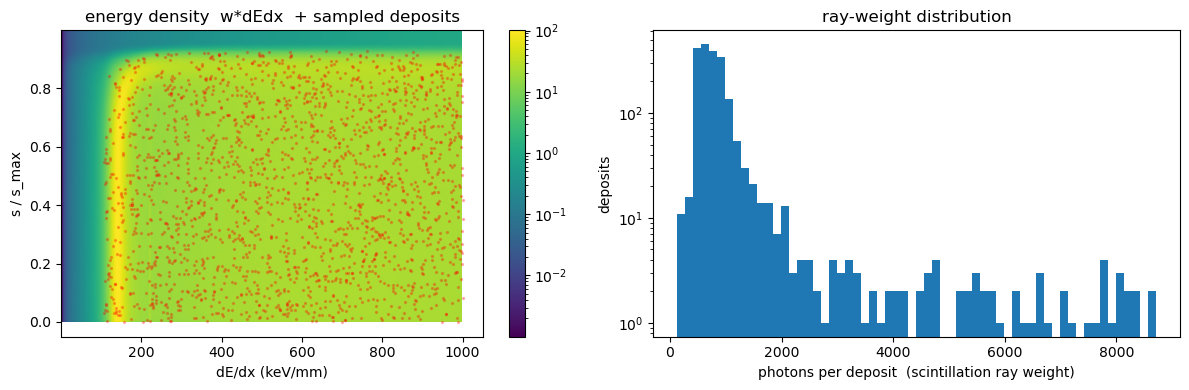

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

im = ax[0].imshow(np.maximum(energy_density, 1e-9).T, origin='lower', aspect='auto',
                  extent=[d_lo, d_hi, s_lo, s_hi], norm=LogNorm(), cmap='viridis')
ax[0].scatter(out['d'][:-1], out['s'][:-1], s=2, c='red', alpha=0.25)
ax[0].set_xlabel('dE/dx (keV/mm)')
ax[0].set_ylabel('s / s_max')
ax[0].set_title('energy density  w*dEdx  + sampled deposits')
fig.colorbar(im, ax=ax[0])

ax[1].hist(out['photons'], bins=60)
ax[1].set_yscale('log')
ax[1].set_xlabel('photons per deposit  (scintillation ray weight)')
ax[1].set_ylabel('deposits')
ax[1].set_title('ray-weight distribution')

plt.tight_layout()
plt.show()

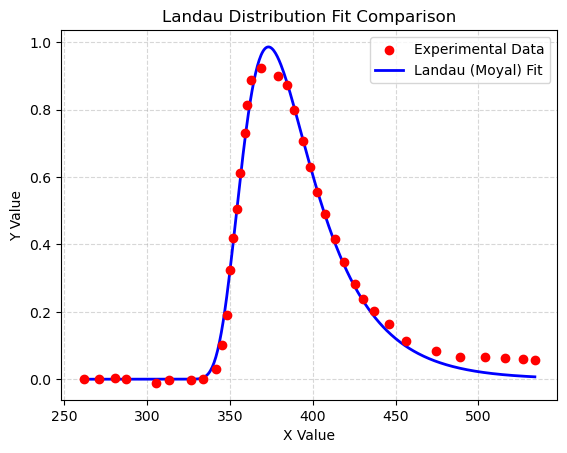

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import moyal

# 1. Raw data points (X, Y)
data = np.array([
    [261.9360437765048, -0.00010444813173737799], [270.9389632291626, -0.0001834211093920679],
    [280.8126234483508, 0.0023615467834221526], [287.4927183517915, -0.0003286294876607698],
    [305.5005952694337, -0.011012909109745728], [313.0499024301598, -0.003184394260277834],
    [326.4090732308779, -0.003301579969056334], [333.66847313814833, 0.001897898979125845],
    [341.5041210307587, 0.030776533646733828], [345.2657822825398, 0.10179616819715731],
    [348.4430434996748, 0.19124198169525242], [350.1600688848166, 0.3228058674374883],
    [351.8837178100199, 0.42015916876270554], [354.4811645202434, 0.5043469104582301],
    [355.9123586765827, 0.6122290929656304], [359.3744321163569, 0.7306197765319484],
    [360.5203045469753, 0.8121886723878198], [362.8288630099064, 0.8884842113486713],
    [368.92099135712937, 0.922641297942117], [379.0901633636714, 0.8988678841525857],
    [384.6131767686975, 0.8725036471928926], [388.98369420304374, 0.7987810987943458],
    [394.22902842857366, 0.7066298239327184], [398.6000553660015, 0.6302756921174772],
    [402.6801560438105, 0.556555691234339], [407.62997848198654, 0.49072279805505703],
    [413.16216294248215, 0.4169900595948768], [418.6933283968146, 0.3485204879680843],
    [425.3856513742147, 0.28267230969635326], [430.3313977877376, 0.23789208385062022],
    [437.017606728158, 0.20362290657921323], [446.31858548357786, 0.1640676348357446],
    [456.4928525209363, 0.11397838687927697], [474.21387920361275, 0.08487557085574471],
    [489.028700308589, 0.06632456365306894], [504.13037164853114, 0.06619209285184136],
    [516.3283849261815, 0.06345351378800279], [526.7838976646076, 0.06073021981661286],
    [534.0448260811231, 0.05803494851471358]
])

x_data = data[:, 0]
y_data = data[:, 1]

# 2. Define the fitting function using Moyal distribution
def landau_approx(x, amp, loc, scale):
    return amp * moyal.pdf(x, loc, scale)

# 3. Perform the fit
initial_guess = [50.0, 368.0, 20.0] 
popt, pcov = curve_fit(landau_approx, x_data, y_data, p0=initial_guess)
amp_fit, loc_fit, scale_fit = popt

# 4. Generate the plot
plt.scatter(x_data, y_data, color='red', label='Experimental Data', zorder=5)
x_fine = np.linspace(min(x_data), max(x_data), 500)
y_fine = landau_approx(x_fine, *popt)
plt.plot(x_fine, y_fine, color='blue', label='Landau (Moyal) Fit', linewidth=2)

plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.title('Landau Distribution Fit Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot out as required
plt.savefig('landau_fit_plot.png', dpi=300, bbox_inches='tight')

In [53]:
popt, pcov 

(array([ 60.19178618, 373.26120442,  14.77305198]),
 array([[0.66123958, 0.11857972, 0.12136923],
        [0.11857972, 0.08722593, 0.04275974],
        [0.12136923, 0.04275974, 0.06712249]]))